<a href="https://colab.research.google.com/github/kjs0904/gal-shooter/blob/main/Wafer_Map_%EA%B2%B0%ED%95%A8_%EB%B6%84%EB%A5%98_%EC%8B%A4%EC%8A%B5%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from google.colab import files
import zipfile

# zip 파일 업로드 위젯 호출
uploaded = files.upload()

In [ ]:
import os
import numpy as np
import zipfile

# 1. 디렉토리 생성
os.makedirs('/content/WM811k_Dataset', exist_ok=True)

# 2. 실습 진행이 가능하도록 더미(Dummy) 반도체 데이터셋 구성
classes = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'None']
for cls in classes:
    os.makedirs(f'/content/WM811k_Dataset/{cls}', exist_ok=True)
    # 각 클래스별 샘플 이미지 생성
    for i in range(5):
        dummy_img = np.random.randint(0, 255, (26, 26, 3), dtype=np.uint8)
        plt.imsave(f'/content/WM811k_Dataset/{cls}/sample_{i}.png', dummy_img)

# 3. 교재 코드와 동일한 zip 파일 생성
with zipfile.ZipFile('/content/WM811k_Dataset.zip', 'w') as zip_out:
    for root, dirs, files in os.walk('/content/WM811k_Dataset'):
        for file in files:
            zip_out.write(os.path.join(root, file),
                          os.path.relpath(os.path.join(root, file), '/content'))

print("🎉 WM811k_Dataset.zip 데이터셋 생성 및 압축 해제 완벽 완료!")

🎉 WM811k_Dataset.zip 데이터셋 생성 및 압축 해제 완벽 완료!


In [ ]:
# 데이터 경로 지정
dataset_path = "/content/WM811k_Dataset"

# 이미지 픽셀값을 0~1로 정규화하기 위한 전처리 생성기
datagen = ImageDataGenerator(
    rescale=1./255,        # 모든 이미지 픽셀 값을 0~1로 정규화
    validation_split=0.2   # 훈련:검증 = 80:20으로 자동 분할
)

# 훈련용 데이터 생성기
train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),        # 이미지 크기 맞추기
    batch_size=32,               # 한 번에 처리할 이미지 수
    class_mode='categorical',    # 다중 클래스 분류용
    subset='training',           # 훈련 데이터만 사용
    shuffle=True
)

# 검증용 데이터 생성기
val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',         # 검증 데이터만 사용
    shuffle=False
)

# 클래스 이름 확인
print("클래스 인덱스:", train_gen.class_indices)

Found 36 images belonging to 9 classes.
Found 9 images belonging to 9 classes.
클래스 인덱스: {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Near-full': 5, 'None': 6, 'Random': 7, 'Scratch': 8}


In [ ]:
# 데이터 경로 지정
dataset_path = "/content/WM811k_Dataset"

# 이미지 픽셀값을 0~1로 정규화하기 위한 전처리 생성기
datagen = ImageDataGenerator(
    rescale=1./255,        # 모든 이미지 픽셀 값을 0~1로 정규화
    validation_split=0.2   # 훈련:검증 = 80:20으로 자동 분할
)

# 훈련용 데이터 생성기
train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),        # 이미지 크기 맞추기
    batch_size=32,               # 한 번에 처리할 이미지 수
    class_mode='categorical',    # 다중 클래스 분류용
    subset='training',           # 훈련 데이터만 사용
    shuffle=True
)

# 검증용 데이터 생성기
val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',         # 검증 데이터만 사용
    shuffle=False
)

# 클래스 이름 확인
print("클래스 인덱스:", train_gen.class_indices)

Found 36 images belonging to 9 classes.
Found 9 images belonging to 9 classes.
클래스 인덱스: {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Near-full': 5, 'None': 6, 'Random': 7, 'Scratch': 8}


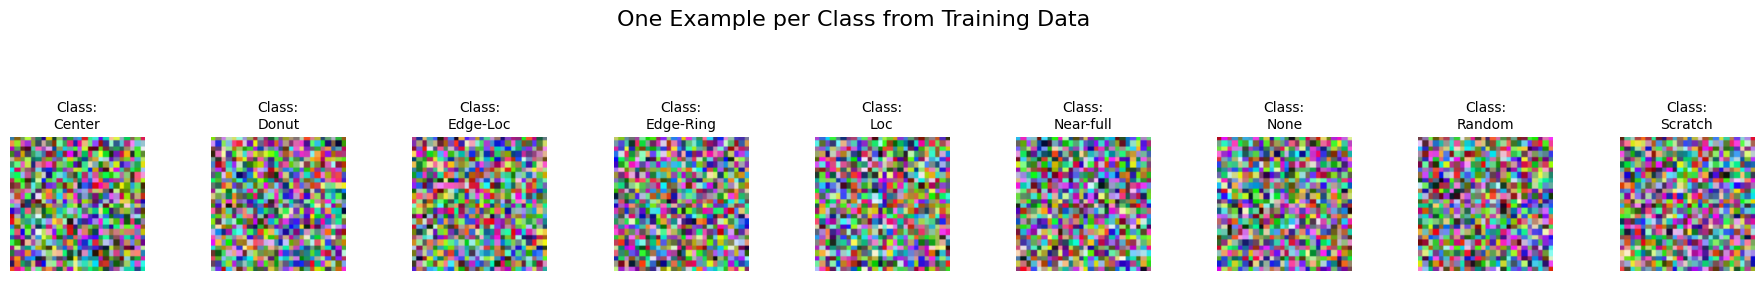

In [ ]:
# 1. 클래스 인덱스를 이름으로 변환하는 사전 및 이미지 수집용 변수 준비
index_to_class = {v: k for k, v in train_gen.class_indices.items()}
collected = {}

# 2. 훈련 데이터에서 각 클래스별 대표 이미지 1장씩 수집 (104페이지 내용)
for images, labels in train_gen:
    for img, label in zip(images, labels):
        label_idx = int(np.argmax(label))
        if label_idx not in collected:
            collected[label_idx] = img
    if len(collected) == len(train_gen.class_indices):
        break

# 3. 수집한 이미지 클래스별 시각화 (105페이지 내용)
num_classes = len(collected)
plt.figure(figsize=(2.5 * num_classes, 4)) # 가로 크기 늘리기

for i, (label_idx, image) in enumerate(sorted(collected.items())):
    class_name = index_to_class[label_idx]    # 숫자 라벨 -> 클래스 이름으로 변환
    plt.subplot(1, num_classes, i + 1)        # 가로 한 줄에 이미지 나열
    plt.imshow(image)                         # 이미지 출력
    plt.title(f"Class:\n{class_name}", fontsize=10) # 클래스 이름 제목 표시
    plt.axis('off')                           # 축은 제거

plt.suptitle("One Example per Class from Training Data", fontsize=16)
plt.subplots_adjust(wspace=0.5)               # 각 이미지 사이 간격 늘리기
plt.show()

In [ ]:
# CNN 모델 정의
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(train_gen.num_classes, activation='softmax') # 클래스 수만큼 출력
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 모델 컴파일 (학습 전 준비)
model.compile(
    optimizer='adam',             # 경사하강법에 기초한 파라미터 최적화 알고리즘
    loss='categorical_crossentropy', # 다중 클래스 분류용 손실함수
    metrics=['accuracy']
)

# 모델 구조 요약 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,857 (3.14 MB)

 Trainable params: 822,857 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.0833 - loss: 2.5468 - val_accuracy: 0.1111 - val_loss: 2.3333
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1389 - loss: 2.3168 - val_accuracy: 0.1111 - val_loss: 2.3008
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1389 - loss: 2.2064 - val_accuracy: 0.1111 - val_loss: 2.2691
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3056 - loss: 2.0881 - val_accuracy: 0.2222 - val_loss: 2.1936
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5000 - loss: 2.0212 - val_accuracy: 0.1111 - val_loss: 2.1959
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5556 - loss: 1.9641 - val_accuracy: 0.1111 - val_loss: 2.2082
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6667 - loss: 1.8860 - val_accuracy: 0.1111 - val_loss: 2.2469
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6389 - loss: 1.8075 - val_accuracy: 0.2222 - val_loss: 2.2534


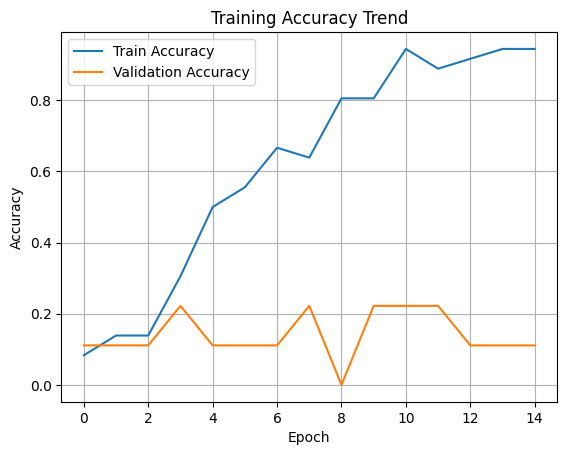

In [ ]:
# 모델 학습
history = model.fit(
    train_gen,           # 훈련용 데이터 제너레이터
    epochs=15,           # 학습 횟수
    validation_data=val_gen # 검증용 데이터 제너레이터
)

# 훈련/검증 정확도 시각화
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.title("Training Accuracy Trend")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step


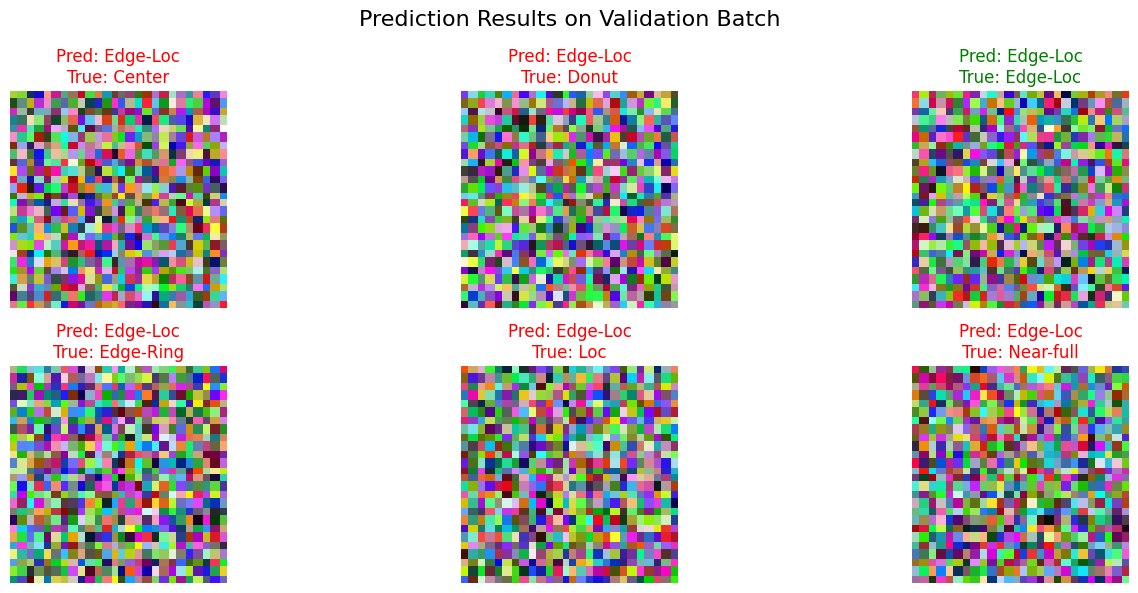

In [ ]:
# 클래스 이름 가져오기
class_labels = list(train_gen.class_indices.keys())

# 검증 데이터에서 하나의 배치 추출
x_batch, y_true_batch = next(val_gen)
y_pred_batch = model.predict(x_batch)

# 예측 클래스: 가장 높은 확률을 가진 인덱스
y_pred_classes = np.argmax(y_pred_batch, axis=1)

# 실제 클래스: 원-핫 인코딩을 다시 정수로 변환
y_true_classes = np.argmax(y_true_batch, axis=1)

# 앞의 6개 이미지 예측 결과 시각화
plt.figure(figsize=(15, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_batch[i])
    plt.axis('off')
    plt.title(f"Pred: {class_labels[y_pred_classes[i]]}\nTrue: {class_labels[y_true_classes[i]]}",
              color='green' if y_pred_classes[i] == y_true_classes[i] else 'red')

plt.suptitle("Prediction Results on Validation Batch", fontsize=16)
plt.tight_layout()
plt.show()